CAPSTONE 2

In [9]:
!pip install tensorflow

In [1]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
!pip install tensorflow

In [2]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [3]:
# Load dataset correctly

df = pd.read_csv(
    r"C:\Users\Acer\Downloads\individual+household+electric+power+consumption\household_power_consumption.txt",
    sep=";",
    na_values="?"
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
#Inspect the data — Checked shape, column names, and previewed the first 5 rows to understand the raw structure.
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
df.head()

Shape: (2075259, 9)

Columns:
['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

First 5 rows:


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [5]:
df.shape

(2075259, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


In [7]:
df.isna().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [8]:
# Check duplicate rows

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [9]:
# Handle missing values

df = df.ffill()

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


In [10]:
# Combine Date and Time — Merged the separate Date and Time columns into a single Datetime column.

df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    dayfirst=True
)

print(df[["Date", "Time", "Datetime"]].head())

         Date      Time            Datetime
0  16/12/2006  17:24:00 2006-12-16 17:24:00
1  16/12/2006  17:25:00 2006-12-16 17:25:00
2  16/12/2006  17:26:00 2006-12-16 17:26:00
3  16/12/2006  17:27:00 2006-12-16 17:27:00
4  16/12/2006  17:28:00 2006-12-16 17:28:00


In [11]:
# Remove old Date and Time columns

df.drop(["Date", "Time"], axis=1, inplace=True)

print(df.head())

   Global_active_power  Global_reactive_power  Voltage  Global_intensity  \
0                4.216                  0.418   234.84              18.4   
1                5.360                  0.436   233.63              23.0   
2                5.374                  0.498   233.29              23.0   
3                5.388                  0.502   233.74              23.0   
4                3.666                  0.528   235.68              15.8   

   Sub_metering_1  Sub_metering_2  Sub_metering_3            Datetime  
0             0.0             1.0            17.0 2006-12-16 17:24:00  
1             0.0             1.0            16.0 2006-12-16 17:25:00  
2             0.0             2.0            17.0 2006-12-16 17:26:00  
3             0.0             1.0            17.0 2006-12-16 17:27:00  
4             0.0             1.0            17.0 2006-12-16 17:28:00  


In [12]:
#Set Datetime as index & resample to hourly — Set Datetime as the index, then averaged minute-level readings into hourly readings to reduce noise.

df.set_index("Datetime", inplace=True)

# Convert minute-wise data into hourly data
df_hourly = df.resample("h").mean()

print("Hourly dataset shape:", df_hourly.shape)

df_hourly.head()

Hourly dataset shape: (34589, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [13]:
#Verify the resampled data — Checked shape, missing values, and data types after resampling.
df.resample("h").mean()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667
...,...,...,...,...,...,...,...
2010-11-26 17:00:00,1.725900,0.061400,237.069667,7.216667,0.0,0.000000,12.866667
2010-11-26 18:00:00,1.573467,0.053700,237.531833,6.620000,0.0,0.000000,0.000000
2010-11-26 19:00:00,1.659333,0.060033,236.741000,7.056667,0.0,0.066667,0.000000


In [14]:
print("Shape:", df_hourly.shape)

print("\nMissing values:")
print(df_hourly.isnull().sum())

print("\nData types:")
print(df_hourly.dtypes)

Shape: (34589, 7)

Missing values:
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

Data types:
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object


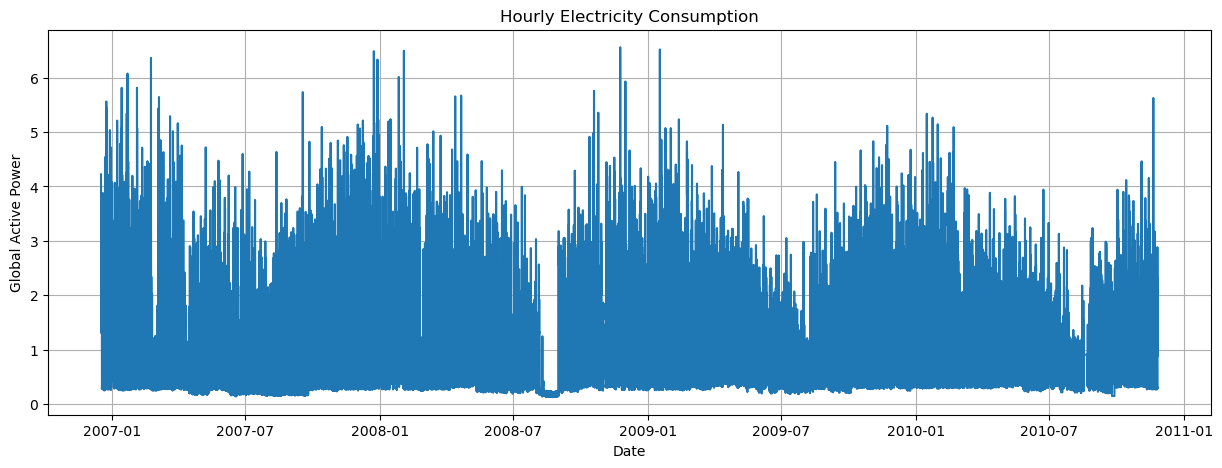

In [15]:
# Visualize hourly consumption — Plotted a line graph of hourly Global Active Power over time to spot trends.

plt.figure(figsize=(15, 5))

plt.plot(
    df_hourly.index,
    df_hourly["Global_active_power"]
)

plt.title("Hourly Electricity Consumption")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.grid(True)

plt.show()

In [16]:
# Select the target feature — Isolated Global_active_power as the single column to forecast.

data = df_hourly[["Global_active_power"]].copy()

print("Shape:", data.shape)
print(data.head())

Shape: (34589, 1)
                     Global_active_power
Datetime                                
2006-12-16 17:00:00             4.222889
2006-12-16 18:00:00             3.632200
2006-12-16 19:00:00             3.400233
2006-12-16 20:00:00             3.268567
2006-12-16 21:00:00             3.056467


In [17]:
#Scale the data — Applied MinMaxScaler to normalize values into the [0, 1] range for stable neural network training.

scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(data)

print("Original first 5 values:")
print(data.head())

print("\nScaled first 5 values:")
print(scaled_data[:5])

Original first 5 values:
                     Global_active_power
Datetime                                
2006-12-16 17:00:00             4.222889
2006-12-16 18:00:00             3.632200
2006-12-16 19:00:00             3.400233
2006-12-16 20:00:00             3.268567
2006-12-16 21:00:00             3.056467

Scaled first 5 values:
[[0.63681623]
 [0.54504495]
 [0.50900588]
 [0.48854974]
 [0.45559722]]


In [18]:
# Create sequences — Built sliding windows of 24 hours (X) mapped to the next hour's value (y) — the supervised learning format for time-series forecasting.

sequence_length = 24

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (34565, 24)
y shape: (34565,)


In [19]:
#Reshape for RNN input — Reshaped X into 3D format (samples, timesteps, features) required by RNN/LSTM layers.

X = X.reshape((X.shape[0], X.shape[1], 1))

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

Final X shape: (34565, 24, 1)
Final y shape: (34565,)


In [20]:
#Train-test split — Split sequences chronologically: 80% training, 20% testing (no shuffling, to preserve time order).

train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (27652, 24, 1)
X_test shape: (6913, 24, 1)
y_train shape: (27652,)
y_test shape: (6913,)


In [21]:
# Building Simple RNN model

model = Sequential([
    SimpleRNN(50, activation="tanh", input_shape=(24, 1)),
    Dropout(0.2),
    Dense(25, activation="relu"),
    Dense(1)
])

model.summary()

C:\Users\Acer\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,901 (15.24 KB)

 Trainable params: 3,901 (15.24 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Compile the model

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [23]:
#Train the RNN — Trained for up to 30 epochs with early stopping (patience=5) to prevent overfitting.
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    shuffle=False
)

Epoch 1/30
778/778 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0105 - mae: 0.0719 - val_loss: 0.0098 - val_mae: 0.0716
Epoch 2/30
778/778 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0090 - mae: 0.0663 - val_loss: 0.0097 - val_mae: 0.0709
Epoch 3/30
778/778 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0089 - mae: 0.0658 - val_loss: 0.0096 - val_mae: 0.0702
Epoch 4/30
778/778 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0090 - mae: 0.0661 - val_loss: 0.0098 - val_mae: 0.0711
Epoch 5/30
778/778 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0089 - mae: 0.0655 - val_loss: 0.0095 - val_mae: 0.0696
Epoch 6/30
778/778 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0089 - mae: 0.0658 - val_loss: 0.0096 - val_mae: 0.0704
Epoch 7/30
778/778 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0089 - mae: 0.0656 - val_loss: 0.0096 - val_mae: 0.0705
Epoch 8/30
778/778 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0089 - mae: 0.0654 - val_loss: 0.0097 - val_mae: 0.0706
Epoch 9/30
778/778 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - lo

In [24]:
#Evaluate the RNN on test data — Computed test loss and test MAE on unseen data.
test_loss, test_mae = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test MAE:", test_mae)

217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0063 - mae: 0.0581
Test Loss: 0.006282936781644821
Test MAE: 0.0581018328666687


In [25]:
#Generate RNN predictions — Predicted on the test set and inverse-transformed both predictions and actual values back to real kilowatt units.
y_pred_scaled = model.predict(X_test)

y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

print("Predictions shape:", y_pred.shape)
print("Actual values shape:", y_test_actual.shape)

217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predictions shape: (6913, 1)
Actual values shape: (6913, 1)


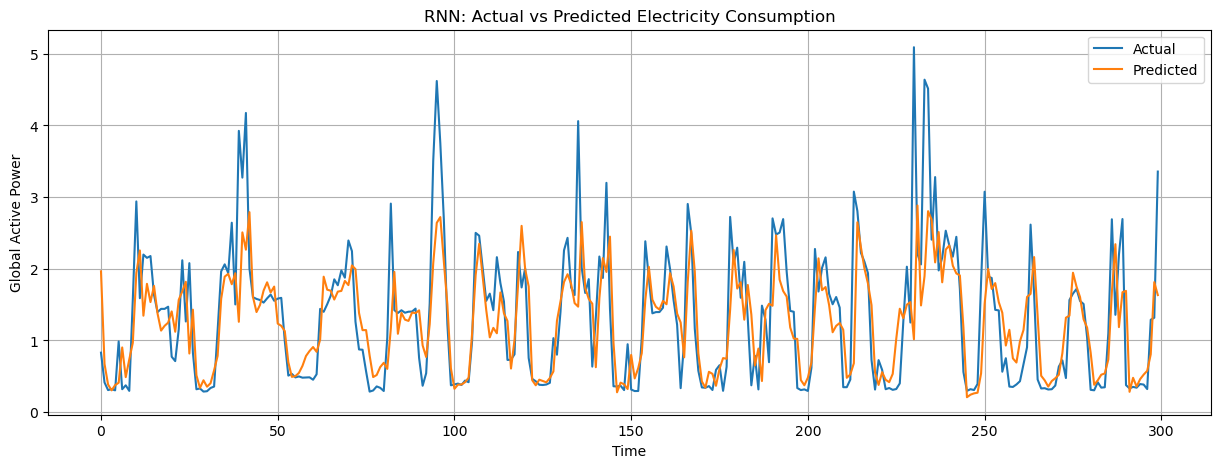

In [26]:
#Plot RNN predictions vs actual — Visualized the first 300 test predictions against real values.
plt.figure(figsize=(15, 5))

plt.plot(y_test_actual[:300], label="Actual")
plt.plot(y_pred[:300], label="Predicted")

plt.title("RNN: Actual vs Predicted Electricity Consumption")
plt.xlabel("Time")
plt.ylabel("Global Active Power")
plt.legend()
plt.grid(True)

plt.show()

In [27]:
#Calculate RNN error metrics — Computed MAE and RMSE in original units.
mae = mean_absolute_error(y_test_actual, y_pred)

mse = mean_squared_error(y_test_actual, y_pred)

rmse = np.sqrt(mse)

print("RNN MAE:", mae)
print("RNN RMSE:", rmse)

RNN MAE: 0.3739743119833537
RNN RMSE: 0.5101916761946109


In [28]:
# LSTM model: learns patterns from the previous 24 hours
lstm_model = Sequential([
    LSTM(50, activation="tanh", input_shape=(24, 1)),  # LSTM layer
    Dropout(0.2),                                      # Reduces overfitting
    Dense(25, activation="relu"),                      # Fully connected layer
    Dense(1)                                           # Predicts next-hour consumption
])

# Display the model architecture
lstm_model.summary()

C:\Users\Acer\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 25)                  │           1,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,701 (45.71 KB)

 Trainable params: 11,701 (45.71 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Compile the LSTM model using MSE loss and MAE metric
lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

# Stop training when validation loss stops improving
early_stop_lstm = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train the LSTM using the same data as the RNN
lstm_history = lstm_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop_lstm],
    shuffle=False
)

Epoch 1/30
778/778 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0129 - mae: 0.0829 - val_loss: 0.0110 - val_mae: 0.0758
Epoch 2/30
778/778 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0098 - mae: 0.0698 - val_loss: 0.0104 - val_mae: 0.0725
Epoch 3/30
778/778 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0094 - mae: 0.0682 - val_loss: 0.0103 - val_mae: 0.0736
Epoch 4/30
778/778 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0091 - mae: 0.0663 - val_loss: 0.0097 - val_mae: 0.0707
Epoch 5/30
778/778 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0089 - mae: 0.0653 - val_loss: 0.0097 - val_mae: 0.0700
Epoch 6/30
778/778 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0088 - mae: 0.0647 - val_loss: 0.0095 - val_mae: 0.0687
Epoch 7/30
778/778 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0087 - mae: 0.0645 - val_loss: 0.0095 - val_mae: 0.0689
Epoch 8/30
778/778 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0087 - mae: 0.0643 - val_loss: 0.0093 - val_mae: 0.0685
Epoch 9/30
778/778 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - lo

In [30]:
# Evaluate the trained LSTM on unseen test data
lstm_test_loss, lstm_test_mae = lstm_model.evaluate(X_test, y_test)

print("LSTM Test Loss:", lstm_test_loss)
print("LSTM Test MAE:", lstm_test_mae)

217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0062 - mae: 0.0554
LSTM Test Loss: 0.006200640928000212
LSTM Test MAE: 0.05539831891655922


In [31]:
# Convert LSTM predictions back to the original electricity units
lstm_pred_scaled = lstm_model.predict(X_test)

lstm_pred = scaler.inverse_transform(lstm_pred_scaled)

# Calculate errors in the original units
lstm_mae = mean_absolute_error(y_test_actual, lstm_pred)
lstm_mse = mean_squared_error(y_test_actual, lstm_pred)
lstm_rmse = np.sqrt(lstm_mse)

print("LSTM MAE:", lstm_mae)
print("LSTM RMSE:", lstm_rmse)

217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
LSTM MAE: 0.3565731760658209
LSTM RMSE: 0.506839376033595


In [32]:
# Compare the final performance of RNN and LSTM

comparison = pd.DataFrame({
    "Model": ["RNN", "LSTM"],
    "MAE": [mae, lstm_mae],
    "RMSE": [rmse, lstm_rmse]
})

print(comparison)

  Model       MAE      RMSE
0   RNN  0.373974  0.510192
1  LSTM  0.356573  0.506839
